# Model Evaluation - Face Mask Detection

This notebook evaluates the trained MobileNetV2 model using:
- Test Accuracy
- Confusion Matrix
- Classification Report
- Real-world image testing

In [3]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image

#Load Model

In [4]:
model = load_model("face_mask_model.h5")

# Load test data

In [10]:
test_data = tf.keras.preprocessing.image_dataset_from_directory(
    "Test",
    image_size=(224,224),
    batch_size=32,
    shuffle=False
)

class_names = test_data.class_names
print("Classes:", class_names)

test_data = test_data.map(lambda x, y: (x/255, y))

Found 992 files belonging to 2 classes.
Classes: ['WithMask', 'WithoutMask']


# Evaluate model

In [11]:
loss, acc = model.evaluate(test_data)

print("Test Accuracy:", acc)

31/31 ━━━━━━━━━━━━━━━━━━━━ 31s 931ms/step - accuracy: 0.9980 - loss: 0.0062
Test Accuracy: 0.9979838728904724


#  Confusion Matrix

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 906ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 873ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 865ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 850ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 898ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 910ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 960ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 901ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 846ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 847ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 858ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 915ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 950ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 866ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 858ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 886ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 995ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 873ms/step
1/1 ━━━━━━

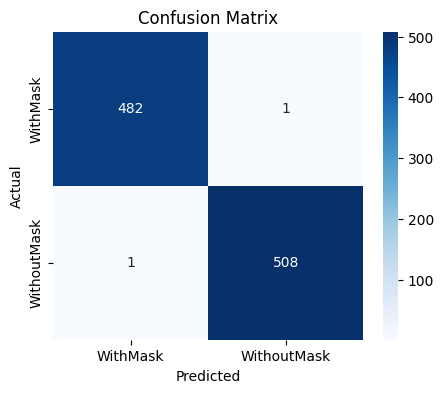

              precision    recall  f1-score   support

    WithMask       1.00      1.00      1.00       483
 WithoutMask       1.00      1.00      1.00       509

    accuracy                           1.00       992
   macro avg       1.00      1.00      1.00       992
weighted avg       1.00      1.00      1.00       992



In [12]:
y_true = []
y_pred = []

for images, labels in test_data:
    preds = model.predict(images)
    preds = (preds > 0.5).astype(int)

    y_pred.extend(preds.flatten())
    y_true.extend(labels.numpy())

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

print(classification_report(y_true, y_pred, target_names=class_names))

# Test on External Image (with 3 conditions)

In [14]:
import os
from tensorflow.keras.preprocessing import image
import numpy as np

image_files = [f for f in os.listdir() if f.endswith(('.jpg', '.jfif', '.png'))]

for img_path in image_files:

    img = image.load_img(img_path, target_size=(224,224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) / 255

    pred = model.predict(img_array)[0][0]

    if pred > 0.75:
        label = "Without Mask "
    elif pred < 0.25:
        label = "With Mask "
    else:
        label = "Uncertain "

    print(f"{img_path} == {label} (score: {pred:.4f})")

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
test.jfif --> With Mask  (score: 0.0000)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
test6.jfif --> With Mask  (score: 0.0000)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
test4.jfif --> With Mask  (score: 0.0124)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step
test7.jfif --> With Mask  (score: 0.0000)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step
test21.jfif --> With Mask  (score: 0.0002)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step
test23.jfif --> With Mask  (score: 0.0000)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step
test24.jfif --> With Mask  (score: 0.0104)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step
test14.jpg --> With Mask  (score: 0.0000)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
test10.jfif --> Without Mask  (score: 0.9917)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
test3.jfif --> Without Mask  (score: 0.9780)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
test15.jpg --> With Mask  (score: 0.0000)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
test13.jfif --> With Mask  (score: 0.0133)
1/1 ━━━━━━━━━━━━━━━━━━━━

## Limitations

Although the model achieved high accuracy on the test dataset, it shows reduced performance in certain real-world scenarios.

Specifically, the model may struggle when:

* The face is far from the camera
* The image is blurry or low quality
* The face is partially visible or not clearly detected

This is because the model relies on clear facial features to distinguish between masked and unmasked faces. When these features are not, the prediction becomes less reliable.

To improve performance, future work could include adding more diverse training data (e.g., different distances, lighting conditions, and image qualities) and integrating a face detection step before classification.
